# NATURAL LANGUAGE INFERENCE: FINE-TUNING BERT

In this section, we will download a pretrained small version of BERT, then fine-tune it for natural language inference on the SNLI dataset.



In [ ]:
import os
import torch
import sys
from utils import spy
from torch import nn
import json
import multiprocessing

## 1. Load Pretrained BERT

In the following, we provide two versions of pretrained BERT: “bert.base” is about as big as the original BERT base model that requires a lot of computational resources to fine-tune, while “bert.small” is a small version to facilitate demonstration.

Either pretrained BERT model contains a “vocab.json” file that defines the vocabulary set and a “pretrained.params” file of the pretrained parameters. We implement the following `load_pretrained_model` function to load pretrained BERT parameters.



In [ ]:
def load_pretrained_model(pretrained_model, num_hiddens, ffn_num_hiddens, 
                          num_heads, num_blks, dropout, max_len, devices):
    data_dir = spy.download_extract(pretrained_model, '../../data')
    vocab = spy.Vocab()
    vocab.idx_to_token = json.load(open(os.path.join(data_dir, 'vocab.json')))
    vocab.token_to_idx = {token : idx for idx, token in enumerate(vocab.idx_to_token)}
    bert = spy.BERTModel(
        len(vocab), num_hiddens, ffn_num_hiddens, num_heads=4, num_blks=2, 
        dropout=0.2, max_len=max_len
    )
    # Load pretrained parameters
    bert.load_state_dict(torch.load(os.path.join(data_dir, 'pretrained.params')))
    return bert, vocab

To facilitate demonstration on most of machines, we will load and fine-tune the small version (“bert.small”) of the pretrained BERT in this section. In the exercise, we will show how to fine-tune the much larger “bert.base” to significantly improve the testing accuracy.

In [3]:
devices = spy.try_all_gpus()
bert, vocab = load_pretrained_model(
    'http://d2l-data.s3-accelerate.amazonaws.com/bert.small.torch.zip',
    num_hiddens=256, ffn_num_hiddens=512, num_heads=4, num_blks=2, 
    dropout=0.1, max_len=512, devices=devices
)

For the downstream task natural language inference on the SNLI dataset, we define a customized dataset class `SNLIBERTDataset`. In each example, the premise and hypothesis form a pair of text sequence and is packed into one BERT input sequence. Segment IDs are used to distinguish the premise and the hypothesis in a BERT input sequence. With the predefined maximum length of a BERT input sequence (`max_len`), the last token of the longer of the input text pair keeps getting removed until `max_len` is met. 

In [10]:
class SNLIBERTDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, max_len, vocab=None):
        premises_hypotheses_tokens = [
            [p_tokens, h_tokens] for [p_tokens, h_tokens] in 
            zip(*[spy.tokenize([s for s in sentence]) for sentence
                in dataset[:2]])]
        self.labels = torch.tensor(dataset[2])
        self.vocab = vocab
        self.max_len = max_len
        self.all_token_ids, self.all_segments, self.all_valid_len = self._preprocess(
            premises_hypotheses_tokens
        )


    def _preprocess(self, premises_hypotheses_tokens):
        pool = multiprocessing.Pool(2)   # Use 2 worker processes
        # Work with each example in premises_hypotheses_tokens
        out = pool.map(self._mp_workers, premises_hypotheses_tokens)
        all_token_ids, all_segments, all_valid_len = [], [], []
        for token_ids, segments, valid_len in out:
            all_token_ids.append(token_ids)
            all_segments.append(segments)
            all_valid_len.append(valid_len)
        return (torch.tensor(all_token_ids, dtype=torch.long), 
                torch.tensor(all_segments, dtype=torch.long),
                torch.tensor(all_valid_len))


    def _mp_workers(self, premises_hypotheses_tokens):
        p_tokens, h_tokens = premises_hypotheses_tokens
        self._truncate_pair_of_tokens(p_tokens, h_tokens)
        tokens, segments = spy.get_tokens_and_segments(
            p_tokens, h_tokens
        )
        token_ids = self.vocab[tokens] + [self.vocab['<pad>']] * \
                    (self.max_len - len(tokens))
        segments = segments + [0] * (self.max_len - len(segments))
        valid_len = len(tokens)
        return token_ids, segments, valid_len


    def _truncate_pair_of_tokens(self, p_tokens, h_tokens):
        # Reserve slots for 2 tokens <sep> and 1 token <cls> for 
        # BERT input
        while len(p_tokens) + len(h_tokens) > self.max_len - 3:
            if len(p_tokens) > len(h_tokens):
                p_tokens.pop()
            else:
                h_tokens.pop()


    def __getitem__(self, index):
        return (self.all_token_ids[index],
                self.all_segments[index],
                self.all_valid_len[index]), self.labels[index]


    def __len__(self):
        return len(self.all_token_ids) 

After downloading the SNLI dataset, we generate training and testing examples by instantiating the `SNLIBERTDataset` class. Such examples will be read in minibatches during training and testing of natural language inference.

In [ ]:
batch_size, max_len, num_workers = 512, 128, 2
data_dir = spy.download_extract('https://nlp.stanford.edu/projects/snli/snli_1.0.zip',
                                folder='../../data',
                                sha1_hash='9fcde07509c7e87ec61c640c1b2753d9041758e4')
train_set = SNLIBERTDataset(spy.read_snli(data_dir, True), max_len, vocab)
test_set = SNLIBERTDataset(spy.read_snli(data_dir, False), max_len, vocab)
train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True, 
                                         num_workers=num_workers)
test_iter = torch.utils.data.DataLoader(test_set, batch_size, shuffle=False, 
                                         num_workers=num_workers)

Processing SNLI dataset: 100%|██████████| 10000/10000 [00:00<00:00, 71629.06it/s]


## 3. Fine-tuning BERT

Fine-tuning BERT for natural language inference requires only an extra MLP consisting of two fully connected layers. This MLP transforms the BERT representation of the special `<cls>` token, which encodes the information of both the premise and the hypothesis, into three outputs of natural language inference: entailment, contradiction, and neutral.

In [12]:
class BERTClassifier(nn.Module):
    def __init__(self, bert):
        super().__init__()
        self.encoder = bert.encoder
        self.hidden = bert.hidden
        self.output = nn.LazyLinear(3)


    def forward(self, inputs):
        tokens_X, segments_X, valid_len_X = inputs
        encoded_X = self.encoder(tokens_X, segments_X, valid_len_X)
        return self.output(self.hidden(encoded_X[:, 0, :]))

In the following, the pretrained BERT model bert is fed into the BERTClassifier instance net for the downstream application. In common implementations of BERT fine-tuning, only the parameters of the output layer of the additional MLP (`net.output`) will be learned from scratch. All the parameters of the pretrained BERT encoder (`net.encoder`) and the hidden layer of the additional MLP (`net.hidden`) will be fine-tuned.

In [13]:
net = BERTClassifier(bert)

Train loss: 0.556
Train acc: 0.774
Test acc: 0.766


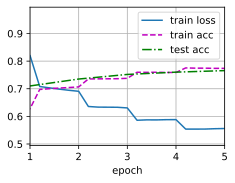

In [14]:
lr, num_epochs = 1e-4, 5
net(next(iter(train_iter))[0])
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction='none')
spy.train(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

Next, we define a function to which take a premise and a hypothesis, converts the input into BERT inputs and give prediction for natural language inference task.

In [ ]:
def predict_bert_snli(net, vocab, max_len, premise, hypothesis):
    """Predict the logical relationship between the premise and the hypothesis"""
    def _truncate_pair_of_tokens(p_tokens, h_tokens):
        # Reserve slots for 2 tokens <sep> and 1 token <cls> for 
        # BERT input
        while len(p_tokens) + len(h_tokens) > max_len - 3:
            if len(p_tokens) > len(h_tokens):
                p_tokens.pop()
            else:
                h_tokens.pop()
                
    net.eval()
    # Prepare data with accordance to BERT inputs
    token_ids, segments, valid_len = [], [], []
    _truncate_pair_of_tokens(premise, hypothesis)
    tokens, segs = spy.get_tokens_and_segments(premise, hypothesis)
    token_ids = vocab[tokens] + [vocab['<pad>']] * (max_len - len(tokens))
    segments = segs + [0] * (max_len - len(segs))
    valid_len = len(tokens)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    tokens_X = torch.tensor(token_ids, device=device).unsqueeze(0) # Batch size = 1
    segments_X = torch.tensor(segments, device=device).unsqueeze(0)
    valid_lens_x = torch.tensor(valid_len, device=device).unsqueeze(0)
    
    label = torch.argmax(net([tokens_X, segments_X, valid_lens_x]), dim=-1)
    
    return 'entailment' if label == 0 else 'contradiction' if label == 1 else 'neutral'

In [21]:
predict_bert_snli(net, vocab, max_len, ['he', 'is', 'good', '.'], ['he', 'is', 'bad', '.'])

'neutral'

In [24]:
predict_bert_snli(net, vocab, max_len, ['two', 'women', 'are', 'hugging', 'each', 'other', '.'], 
             ['two', 'women', 'are', 'showing', 'affection', '.'])

'entailment'

In [27]:
predict_bert_snli(net, vocab, max_len, ['A', 'man', 'is', 'running', 'a', 'coding', 'example', '.'], 
             ['The', 'man', 'is', 'sleeping', '.'])

'contradiction'

In [28]:
predict_bert_snli(net, vocab, max_len, ['A', 'man', 'is', 'running', 'a', 'coding', 'example', '.'], 
             ['The', 'woman', 'is', 'sleeping', '.'])

'contradiction'

In [30]:
predict_bert_snli(net, vocab, max_len, ['The', 'musicians', 'are', 'performing', 'for', 'us', '.'], 
             ['The', 'musicians', 'are', 'famous', '.'])

'neutral'

In [31]:
predict_bert_snli(net, vocab, max_len, ['They', 'are', 'screaming', 'at', 'each', 'other', '.'], 
             ['They', "don't", 'like', 'each', 'other', '.'])

'neutral'

In [32]:
predict_bert_snli(net, vocab, max_len, ['They', 'are', 'screaming', 'at', 'each', 'other', '.'], 
             ['They', 'love', 'each', 'other', '.'])

'neutral'